In [65]:
import pandas as pd
import numpy as np
import pickle
import warnings
from pmdarima import auto_arima
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_percentage_error
warnings.filterwarnings(
    "ignore",
    message=".*force_all_finite.*",
    category=FutureWarning,
    module="sklearn"
)

In [19]:
with open('../data/datasets/data_cleaned.pkl', 'rb') as f:
    states_dfs = pickle.load(f)

In [ ]:
target = 'residential_electricity_price'
state = 'ME'
df = states_dfs[state]

In [ ]:
class BoostedSarima:

    def __init__(self, n_componets=5, horizon=12):
        self.n_components = n_componets
        self.horizon = horizon
        self.sarima_forecast = None
        self.base_preds = None
        self.preds = None
        self.y_train = None
        self.y_resid_train = None
        self.X_train = None
        self.pca_forecast = None
        self.X_pca = None
        self.pca_pipe = Pipeline(
                                 [
                                    ('scaler', StandardScaler()), 
                                    ('pca', PCA(n_components=n_componets))
                                 ]
                                )
        self.lr_model = None


    def fit(self, X: pd.DataFrame, y: pd.Series):
        self.y_train = y
        self.X_train = X
        self.y_resid_train = y.iloc[-self.horizon:]

        self._get_base_preds()
        self._get_PCA_Forecast()
        self._fit_resid()

    def predict(self):
        self.sarima_forecast = self.sarima_base.predict(self.horizon)
        resid_forecast = self.lr_model.predict(self.pca_forecast)
        self.preds = self.sarima_forecast + resid_forecast
        return self.preds
        


    def _get_base_preds(self):
        self.sarima_base = auto_arima(
            self.y_train, 
            seasonal=True,
            m=self.horizon,
            error_action='ignore',
            max_q = 20,
            max_p = 3,
            max_order = 25
        )
        start = len(self.y_train) - self.horizon
        self.base_preds = self.sarima_base.predict_in_sample(self.horizon, start=start)

    def _get_PCA_Forecast(self):
        self.X_pca = self.pca_pipe.fit_transform(self.X_train)
        self.pca_forecast = np.zeros(shape=(self.horizon, self.n_components))
        self.pca_sarimas = {}
        for i in range(self.n_components):
            y = self.X_pca[:,i]
            sarima = auto_arima(
                y, 
                seasonal=True,
                m=self.horizon,
                error_action='ignore',
                max_q = 20,
                max_p = 3,
                max_order = 25
            )
            start = len(self.y_train) - self.horizon
            self.pca_forecast[:, i] = sarima.predict(self.horizon, start=start)
            self.pca_sarimas[f'component {i+1}'] = sarima

    def _fit_resid(self):
        start_idx = len(self.y_train) - self.horizon
        X = self.X_pca[start_idx:, :]
        resid = self.y_resid_train - self.base_preds
        self.lr_model = LinearRegression()
        self.lr_model.fit(X, resid)

In [57]:
X, y = df.drop(columns=[target]), df[target]

X_train = X.iloc[:-24]
y_train = y.iloc[:-24]

In [62]:
horizon=24
model = BoostedSarima(n_componets=3, horizon=horizon)
model.fit(X_train, y_train)

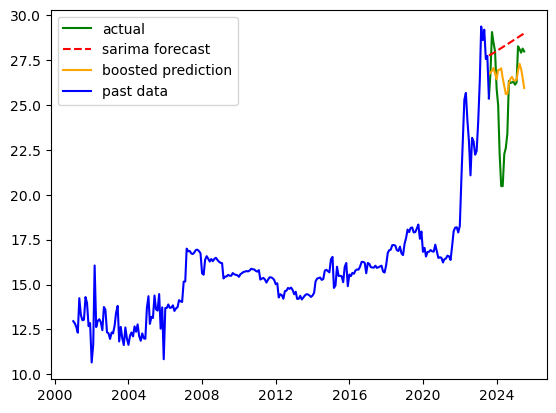

2023-08-01    26.715160
2023-09-01    26.793192
2023-10-01    26.896046
2023-11-01    27.062377
2023-12-01    26.750773
2024-01-01    26.426701
2024-02-01    26.958956
2024-03-01    26.949958
2024-04-01    27.046455
2024-05-01    26.488714
2024-06-01    26.055440
2024-07-01    25.607551
2024-08-01    25.611374
2024-09-01    26.199335
2024-10-01    26.463361
2024-11-01    26.559593
2024-12-01    26.380051
2025-01-01    26.358430
2025-02-01    26.409245
2025-03-01    26.919508
2025-04-01    27.291471
2025-05-01    27.008311
2025-06-01    26.507136
2025-07-01    25.945190
Freq: MS, dtype: float64
2024-08-01    23.39
2024-09-01    26.34
2024-10-01    26.22
2024-11-01    26.26
2024-12-01    26.29
2025-01-01    26.13
2025-02-01    26.26
2025-03-01    28.27
2025-04-01    28.11
2025-05-01    27.91
2025-06-01    28.14
2025-07-01    27.98
Freq: MS, Name: residential_electricity_price, dtype: float64


In [ ]:
preds = model.predict()
plt.plot(y[-horizon:].index, y[-horizon:], color='green', label='actual')
plt.plot(y[-horizon:].index, model.sarima_forecast, label='sarima forecast', color='red', linestyle='--')
plt.plot(y[-horizon:].index, preds, label='boosted prediction', color='orange')
plt.plot(y.index[:-horizon+1], y[:-horizon+1], color='blue', label='past data')
plt.legend()
plt.show()


In [68]:
sarima_mape = mean_absolute_percentage_error(model.sarima_forecast, y[-horizon:])
boosted_mape = mean_absolute_percentage_error(preds, y[-horizon:])
print(f'MAPE vs SARIMA: {sarima_mape}')
print(f'MAPE vs BOOSTED: {boosted_mape}')

MAPE vs SARIMA: 0.09765494171788343
MAPE vs BOOSTED: 0.06718736916470058
